In [ ]:
import numpy as np
import matplotlib.pyplot as plt

In [20]:
class LinearRegressionGD:
    def __init__(self, learning_rate=0.0001, n_iters=1000):
        self.lr = learning_rate
        self.n_iters = n_iters
        self.theta_0 = 0.0  # Bias / Intercept
        self.theta_1 = 0.0  # Weight / Slope
        self.sse_history = []

    def fit(self, X, y):
        n = len(X)
        for _ in range(self.n_iters):
            y_pred = self.theta_0 + self.theta_1 * X
            error = y_pred - y
            sse = np.sum(error ** 2)
            self.sse_history.append(sse)
            
            # حساب المشتقات (Gradients)
            d_theta_0 = (2 / n) * np.sum(error)
            d_theta_1 = (2 / n) * np.sum(error * X)
            
            self.theta_0 -= self.lr * d_theta_0
            self.theta_1 -= self.lr * d_theta_1

    def predict(self, X):
        return self.theta_0 + self.theta_1 * np.array(X)

    def plot_training(self, X, y):
        plt.figure(figsize=(12, 4))
        
        plt.subplot(1, 2, 1)
        plt.plot(self.sse_history, color='red')
        plt.title('SSE over Iterations')
        plt.xlabel('Iterations')
        plt.ylabel('SSE')
        plt.grid(True)
        
        plt.subplot(1, 2, 2)
        plt.scatter(X, y, color='blue', label='Data Points')
        plt.plot(X, self.predict(X), color='black', label='Regression Line')
        plt.title('Fitted Line')
        plt.xlabel('X (Size)')
        plt.ylabel('y (Price)')
        plt.legend()
        plt.grid(True)
        plt.show()

In [21]:
X = np.array([50, 60, 70, 80, 90], dtype=float)
y = np.array([150, 180, 210, 240, 270], dtype=float)

In [23]:
model = LinearRegressionGD(learning_rate=0.0001, n_iters=1000)

model.fit(X, y)

In [24]:
print(f"theta_0 (Intercept): {model.theta_0:.4f}")
print(f"theta_1 (Slope): {model.theta_1:.4f}")

theta_0 (Intercept): 0.0408
theta_1 (Slope): 2.9994


In [25]:
pred_70 = model.predict(70)
print(f"Predicted price for size 70: {pred_70:.2f}")

Predicted price for size 70: 210.00


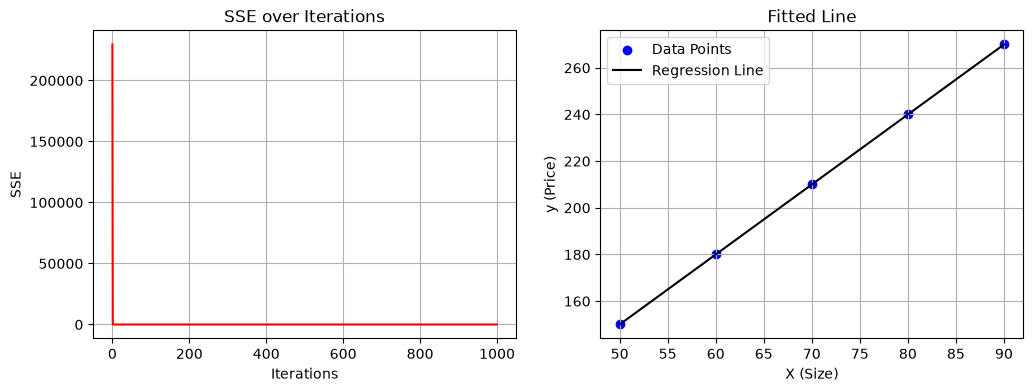

In [26]:
model.plot_training(X, y)

In [27]:
model_large = LinearRegressionGD(learning_rate=0.01, n_iters=50)
model_large.fit(X, y)
print(f"Final SSE with large LR: {model_large.sse_history[-1]}")

model_small = LinearRegressionGD(learning_rate=1e-7, n_iters=50)
model_small.fit(X, y)
print(f"Final SSE with small LR: {model_small.sse_history[-1]}")

Final SSE with large LR: 6.199747459552945e+201
Final SSE with small LR: 207653.98578378005
